# Compare Two Training Runs
Set the two log directories below. The notebook will compare train, val, and test metrics, and show metadata and data paths for each run.

In [1]:
from pathlib import Path

RUN_A = Path("/home/lukasb/Documents/NoisyLabelDefectDetection/logs/train/SurfaceDefectDetection/full_cleaned_new/2026-02-16_10-48-13_ce_medium")
RUN_B = Path("/home/lukasb/Documents/NoisyLabelDefectDetection/logs/train/SurfaceDefectDetection/synthetic/2026-02-17_17-21-14_ce")

In [11]:
import pandas as pd
import numpy as np
import yaml

TRAIN_COLS = [
    "train/acc",
    "train/f1_macro",
    "train/f1_weighted",
    "train/loss",
    "train/precision_macro",
    "train/recall_macro",
]

VAL_COLS = [
    "val/acc",
    "val/f1_macro",
    "val/f1_weighted",
    "val/loss",
    "val/precision_macro",
    "val/recall_macro",
]

TEST_KEEP = [
    "test/acc",
    "test/f1_macro",
    "test/f1_weighted",
    "test/loss",
    "test/precision_macro",
    "test/recall_macro",
]

In [12]:
def load_config(log_dir: Path) -> dict:
    config_path = log_dir / ".hydra" / "config.yaml"
    return yaml.safe_load(config_path.read_text())

def extract_metadata(cfg: dict) -> dict:
    data = cfg.get("data", {})
    model = cfg.get("model", {})
    net = model.get("net", {})
    trainer = cfg.get("trainer", {})
    return {
        "experiment_name": cfg.get("experiment_name"),
        "run_name_postfix": cfg.get("run_name_postfix"),
        "seed": cfg.get("seed"),
        "n_runs": cfg.get("n_runs"),
        "max_epochs": trainer.get("max_epochs"),
        "batch_size": data.get("batch_size"),
        "transforms": data.get("transforms"),
        "net_variant": net.get("variant"),
        "optimizer": (model.get("optimizer", {}) or {}).get("_target_"),
        "criterion": (model.get("criterion", {}) or {}).get("_target_"),
        "classes": data.get("classes"),
    }

def extract_data_paths(cfg: dict) -> dict:
    data = cfg.get("data", {})
    return {
        "train_path": data.get("train_path"),
        "val_path": data.get("val_path"),
        "test_path": data.get("test_path"),
        "syn_path": data.get("syn_path"),
    }

In [14]:
cfg_a = load_config(RUN_A)
cfg_b = load_config(RUN_B)

meta_a = extract_metadata(cfg_a)
meta_b = extract_metadata(cfg_b)

paths_a = extract_data_paths(cfg_a)
paths_b = extract_data_paths(cfg_b)

meta_table = pd.DataFrame({"run_a": meta_a, "run_b": meta_b})
paths_table = pd.DataFrame({"run_a": paths_a, "run_b": paths_b})

In [15]:
display(meta_table)
display(paths_table)

,run_a,run_b
experiment_name,full_cleaned_new,synthetic
run_name_postfix,ce_medium,ce
seed,42,42
n_runs,5,5
max_epochs,200,200
batch_size,32,32
transforms,medium,medium
net_variant,large,large
optimizer,torch.optim.SGD,torch.optim.SGD
criterion,src.models.components.loss.CELoss,src.models.components.loss.CELoss


,run_a,run_b
train_path,/srv/defectDetectionDataset/surfaceClassificat...,/srv/defectDetectionDataset/surfaceClassificat...
val_path,/srv/defectDetectionDataset/surfaceClassificat...,/srv/defectDetectionDataset/surfaceClassificat...
test_path,/srv/defectDetectionDataset/surfaceClassificat...,/srv/defectDetectionDataset/surfaceClassificat...
syn_path,None,/srv/defectDetectionDataset/sourceSets/synthetic


In [17]:
def load_test_statistics(log_dir: Path) -> pd.DataFrame:
    summary_path = log_dir / "summary" / "summary_statistics.csv"
    return pd.read_csv(summary_path)

def list_run_dirs(log_dir: Path) -> list[Path]:
    run_dirs = [p for p in log_dir.iterdir() if p.is_dir() and p.name.startswith("run_")]
    return sorted(run_dirs, key=lambda p: int(p.name.split("_")[1]))

def load_run_tain_val_metrics(run_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    metrics_path = run_dir / "metrics.csv"
    if not metrics_path.exists():
        return pd.DataFrame(), pd.DataFrame()
    df = pd.read_csv(metrics_path)
    train_df = df[df["train/acc"].notna()]
    val_df = df[df["val/acc"].notna()]
    return train_df, val_df

def load_train_val_metrics(log_dir: Path) -> list[tuple[pd.DataFrame, pd.DataFrame]]:
    run_dirs = list_run_dirs(log_dir)
    dfs = []
    for run_dir in run_dirs:
        train_df, val_df = load_run_tain_val_metrics(run_dir)
        if not train_df.empty and not val_df.empty:
            dfs.append((train_df, val_df))
    return dfs

def load_test_metrics(log_dir: Path) -> pd.DataFrame:
    path = log_dir / "summary" / "all_runs_metrics.csv"
    return pd.read_csv(path)

def select_test_metrics(summary_df: pd.DataFrame) -> pd.DataFrame:
    df = summary_df.set_index("metric")
    available = [m for m in TEST_KEEP if m in df.index]
    cols = ["mean", "std", "min", "max"]
    return df.loc[available, cols]

In [18]:
test_statistic_a = load_test_statistics(RUN_A)
test_statistic_b = load_test_statistics(RUN_B)

trainval_a = load_train_val_metrics(RUN_A)
trainval_b = load_train_val_metrics(RUN_B)

test_sel_a = select_test_metrics(test_statistic_a)
test_sel_b = select_test_metrics(test_statistic_b)

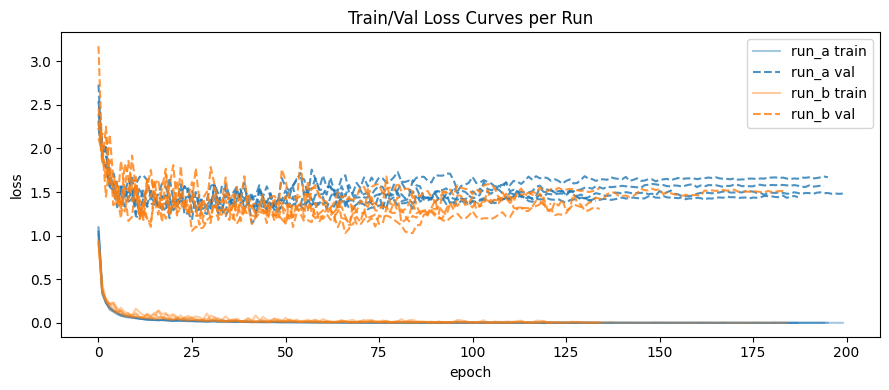

In [19]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))

for i, (train_df, val_df) in enumerate(trainval_a):
    ax.plot(train_df["epoch"], train_df["train/loss"], color="C0", alpha=0.4, label="run_a train" if i == 0 else None)
    ax.plot(val_df["epoch"], val_df["val/loss"], color="C0", alpha=0.8, linestyle="--", label="run_a val" if i == 0 else None)

for i, (train_df, val_df) in enumerate(trainval_b):
    ax.plot(train_df["epoch"], train_df["train/loss"], color="C1", alpha=0.4, label="run_b train" if i == 0 else None)
    ax.plot(val_df["epoch"], val_df["val/loss"], color="C1", alpha=0.8, linestyle="--", label="run_b val" if i == 0 else None)

ax.set_title("Train/Val Loss Curves per Run")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## Test Metrics (Summary Statistics)

In [20]:
test_compare = pd.concat(
    [test_sel_a.add_prefix("run_a/"), test_sel_b.add_prefix("run_b/")],
    axis=1
)

test_compare

,run_a/mean,run_a/std,run_a/min,run_a/max,run_b/mean,run_b/std,run_b/min,run_b/max
metric,,,,,,,,
test/acc,0.792748,0.003746,0.786208,0.795325,0.791726,0.008906,0.776119,0.798280
test/f1_macro,0.731596,0.006251,0.725881,0.739337,0.738912,0.009739,0.725759,0.747796
test/f1_weighted,0.768114,0.009662,0.757186,0.780954,0.785723,0.012877,0.765036,0.799759
test/loss,1.396223,0.099973,1.279771,1.488147,1.281241,0.135821,1.118741,1.457208
test/precision_macro,0.727605,0.008218,0.718467,0.737158,0.741338,0.007460,0.730814,0.751143
test/recall_macro,0.792748,0.003746,0.786208,0.795325,0.791726,0.008906,0.776119,0.798280


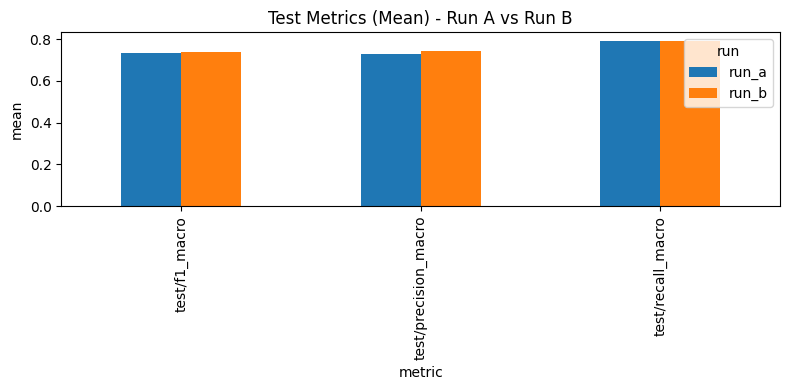

In [22]:
metrics = ["test/f1_macro", "test/precision_macro", "test/recall_macro"]
plot_df = test_compare.loc[metrics, ["run_a/mean", "run_b/mean"]].rename(
    columns={"run_a/mean": "run_a", "run_b/mean": "run_b"}
)

ax = plot_df.plot(kind="bar", figsize=(8, 4))
ax.set_title("Test Metrics (Mean) - Run A vs Run B")
ax.set_xlabel("metric")
ax.set_ylabel("mean")
ax.legend(title="run")
plt.tight_layout()
plt.show()

In [23]:
def gather_class_stats(summary_df: pd.DataFrame, classes: list[str], prefix: str = "test/") -> pd.DataFrame:
    df = summary_df.set_index("metric")
    rows = []
    for cls in classes:
        rows.append({
            "class": cls,
            "precision_mean": df.at[f"{prefix}precision_{cls}", "mean"] if f"{prefix}precision_{cls}" in df.index else np.nan,
            "recall_mean": df.at[f"{prefix}recall_{cls}", "mean"] if f"{prefix}recall_{cls}" in df.index else np.nan,
            "f1_mean": df.at[f"{prefix}f1_{cls}", "mean"] if f"{prefix}f1_{cls}" in df.index else np.nan,
        })
    return pd.DataFrame(rows).set_index("class")

classes_a = cfg_a.get("data", {}).get("classes", [])
classes_b = cfg_b.get("data", {}).get("classes", [])

class_stats_a = gather_class_stats(test_statistic_a, classes_a)
class_stats_b = gather_class_stats(test_statistic_b, classes_b)

display(class_stats_a)
display(class_stats_b)

,precision_mean,recall_mean,f1_mean
class,,,
black_stain,0.318870,0.906250,0.471390
corrosion,0.832899,0.725000,0.774879
crack,0.490581,0.889655,0.631877
deformation,0.907541,0.729730,0.808832
missing_part,0.810575,0.711429,0.756844
ok,0.621961,0.839130,0.714231
other,0.662821,0.669565,0.664202
silicate_stain,0.954248,0.976471,0.965042
water_stain,0.948946,0.687500,0.797067


,precision_mean,recall_mean,f1_mean
class,,,
black_stain,0.322984,0.962500,0.482608
corrosion,0.867319,0.756522,0.806935
crack,0.578985,0.896552,0.702543
deformation,0.919966,0.759459,0.831472
missing_part,0.702137,0.685714,0.692515
ok,0.666946,0.833333,0.738446
other,0.680381,0.660870,0.669899
silicate_stain,0.950637,0.870588,0.908289
water_stain,0.982689,0.700000,0.817503


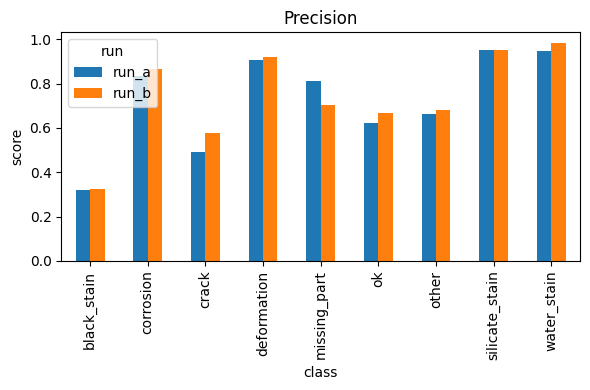

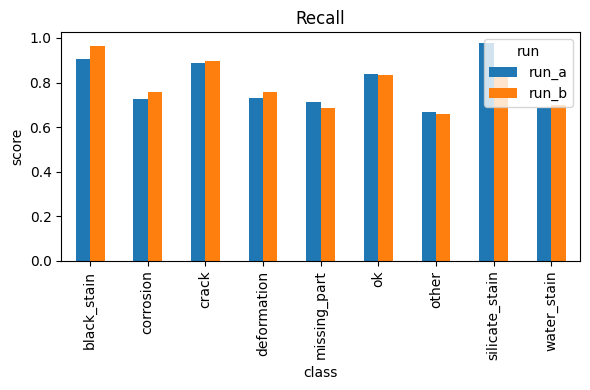

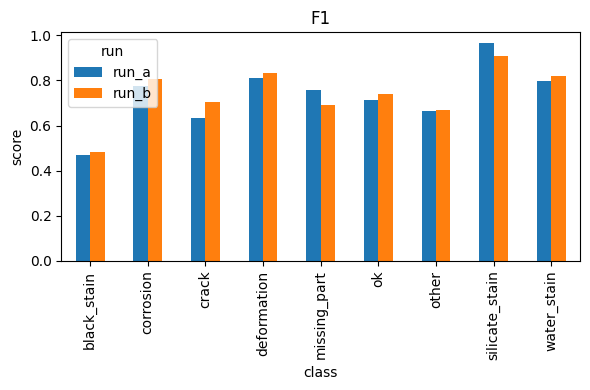

In [ ]:
metrics = ["precision_mean", "recall_mean", "f1_mean"]

plot_df = (
    class_stats_a[metrics]
    .add_prefix("run_a_")
    .join(class_stats_b[metrics].add_prefix("run_b_"))
)

for m in metrics:
    fig, ax = plt.subplots(figsize=(6, 4))
    cols = [f"run_a_{m}", f"run_b_{m}"]
    plot_df[cols].rename(columns={f"run_a_{m}": "run_a", f"run_b_{m}": "run_b"}).plot(
        kind="bar", ax=ax
    )
    ax.set_title(m.replace("_mean", "").capitalize())
    ax.set_xlabel("class")
    ax.set_ylabel("score")
    ax.legend(title="run")
    plt.tight_layout()
    plt.show()